In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv
/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the retail sales dataset
file_path = "/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset loaded successfully!
Dataset Shape: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0


## 2. Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to understand the distribution of customer age, quantity purchased, unit price, and total transaction amount.

In [57]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [58]:
print("Numerical Summary:")

display(df.describe())

Numerical Summary:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [59]:
print("Gender Distribution:")
display(df["Gender"].value_counts())

print("\nProduct Category Distribution:")
display(df["Product Category"].value_counts())

Gender Distribution:


Gender
Female    510
Male      490
Name: count, dtype: int64


Product Category Distribution:


Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [60]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())

Minimum Date: 2023-01-01 00:00:00
Maximum Date: 2024-01-01 00:00:00


## 3. Time Series Sales Analysis

Monthly and quarterly sales trends are analyzed to identify changes in transaction revenue over time and determine periods with higher or lower sales.

In [61]:
# Calculate monthly sales
monthly_sales = (
    df.set_index("Date")
      .resample("ME")["Total Amount"]
      .sum()
)

print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


Date
2023-01-31    35450
2023-02-28    44060
2023-03-31    28990
2023-04-30    33870
2023-05-31    53150
2023-06-30    36715
2023-07-31    35465
2023-08-31    36960
2023-09-30    23620
2023-10-31    46580
2023-11-30    34920
2023-12-31    44690
2024-01-31     1530
Freq: ME, Name: Total Amount, dtype: int64

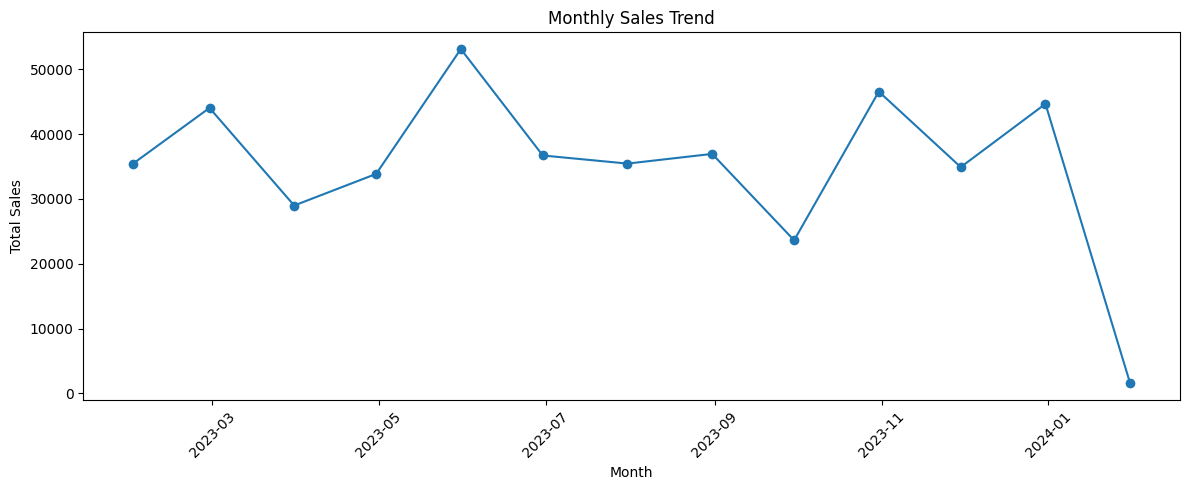

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows how total revenue changes across the period covered by the dataset. Peaks represent months with higher transaction revenue, while lower points indicate comparatively weaker sales periods. These variations can help identify seasonal or demand-related changes in customer purchasing behavior.

In [63]:
# Calculate quarterly sales
quarterly_sales = (
    df.set_index("Date")
      .resample("QE")["Total Amount"]
      .sum()
)

print("Quarterly Sales:")
display(quarterly_sales)

Quarterly Sales:


Date
2023-03-31    108500
2023-06-30    123735
2023-09-30     96045
2023-12-31    126190
2024-03-31      1530
Freq: QE-DEC, Name: Total Amount, dtype: int64

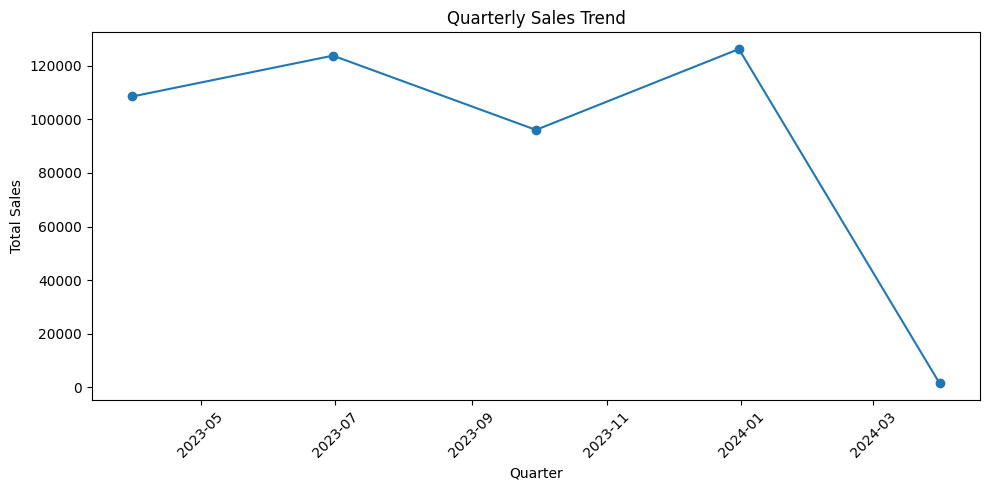

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend provides a broader view of revenue movement by grouping transactions into three-month periods. Compared with monthly analysis, quarterly aggregation reduces short-term fluctuations and makes broader sales patterns easier to identify.

## 4. Customer Demographics Analysis

Customer demographics are analyzed using age groups and gender to understand which customer segments contribute most to retail transactions.

In [65]:
# Create customer age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=True
)

print("Age Group Distribution:")
display(df["Age Group"].value_counts().sort_index())

Age Group Distribution:


Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

In [66]:
age_group_sales = (
    df.groupby("Age Group", observed=True)["Total Amount"]
      .sum()
      .reset_index()
)

print("Sales by Age Group:")
display(age_group_sales)

Sales by Age Group:


,Age Group,Total Amount
0,Under 18,11215
1,18-25,73335
2,26-35,98480
3,36-45,91870
4,46-55,100690
5,56-65,80410


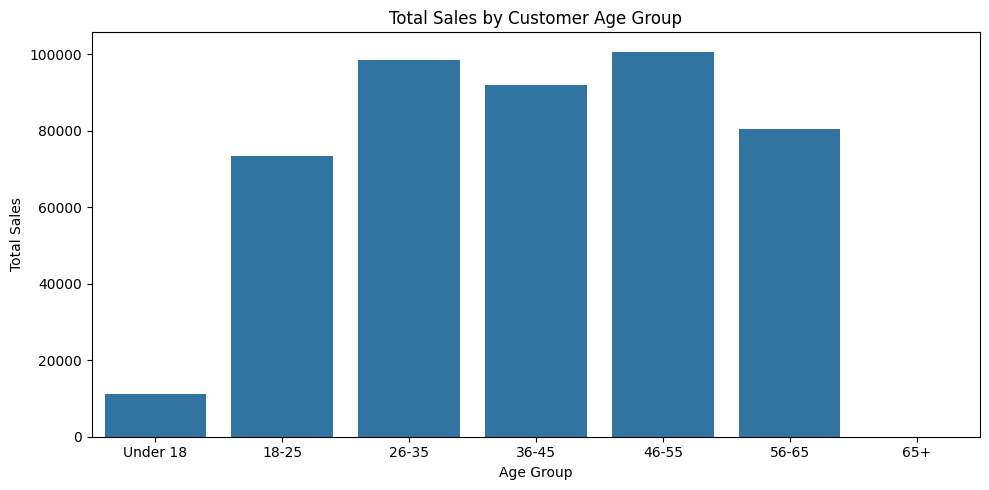

In [67]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_group_sales,
    x="Age Group",
    y="Total Amount"
)

plt.title("Total Sales by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

The age-group analysis shows differences in purchasing contribution across customer segments. The age group with the highest total sales represents an important customer segment for targeted marketing and promotional strategies.

In [68]:
gender_sales = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .reset_index()
)

print("Sales by Gender:")
display(gender_sales)

Sales by Gender:


,Gender,Total Amount
0,Female,232840
1,Male,223160


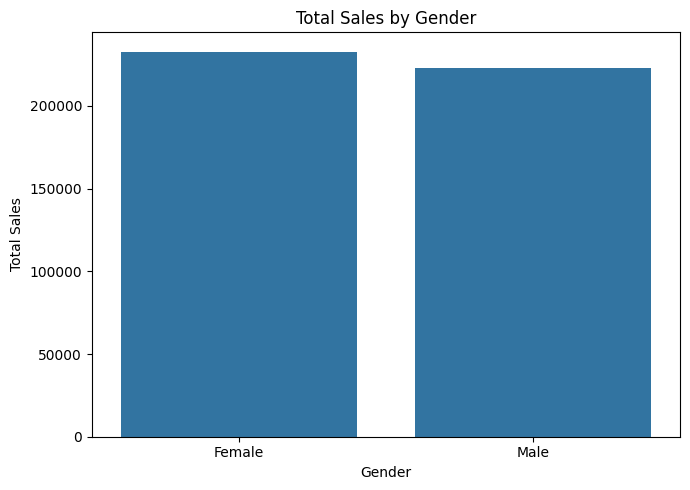

In [69]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_sales,
    x="Gender",
    y="Total Amount"
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [70]:
gender_age_sales = (
    df.groupby(
        ["Age Group", "Gender"],
        observed=True
    )["Total Amount"]
    .sum()
    .reset_index()
)

display(gender_age_sales)

,Age Group,Gender,Total Amount
0,Under 18,Female,7940
1,Under 18,Male,3275
2,18-25,Female,31530
3,18-25,Male,41805
4,26-35,Female,55115
5,26-35,Male,43365
6,36-45,Female,46735
7,36-45,Male,45135
8,46-55,Female,53310
9,46-55,Male,47380


### Observation

The gender-level sales comparison shows the contribution of different customer groups to total revenue. Differences in sales between genders can help businesses understand customer composition and design more targeted marketing campaigns.

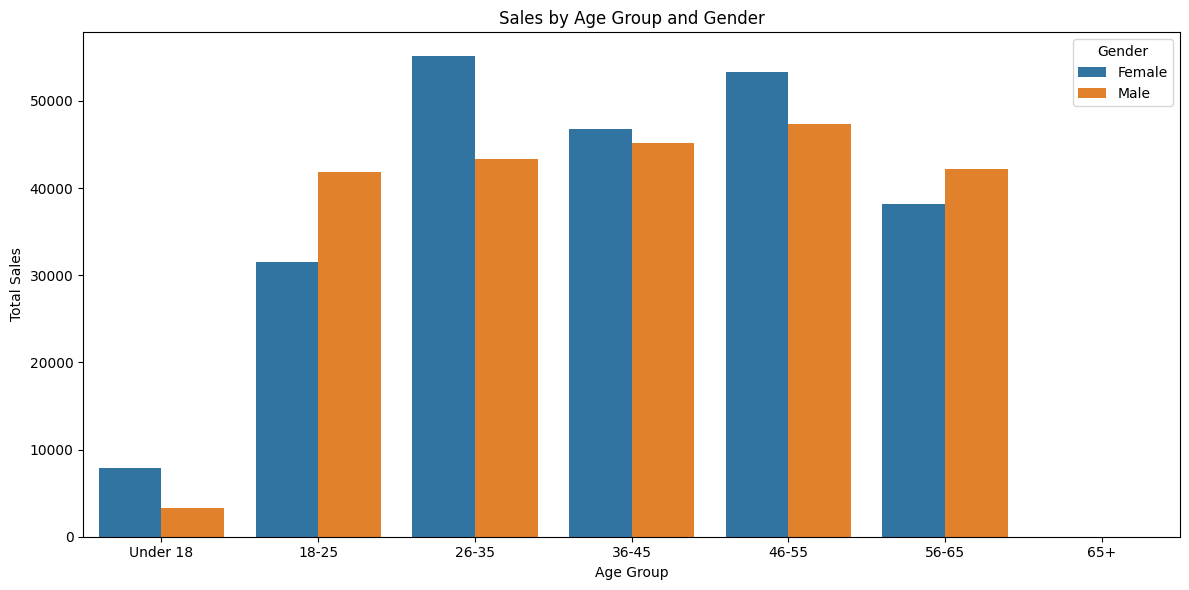

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=gender_age_sales,
    x="Age Group",
    y="Total Amount",
    hue="Gender"
)

plt.title("Sales by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 5. Product and Category Analysis

The dataset does not contain an individual product-name column. Therefore, product-level ranking is not possible from the available data.

Instead, product categories are analyzed by transaction volume and total revenue to identify the strongest-performing categories.

In [72]:
category_transactions = (
    df["Product Category"]
    .value_counts()
    .reset_index()
)

category_transactions.columns = [
    "Product Category",
    "Transaction Count"
]

print("Transactions by Product Category:")
display(category_transactions)

Transactions by Product Category:


,Product Category,Transaction Count
0,Clothing,351
1,Electronics,342
2,Beauty,307


In [73]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue.columns = [
    "Product Category",
    "Total Revenue"
]

print("Revenue by Product Category:")
display(category_revenue)

Revenue by Product Category:


,Product Category,Total Revenue
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


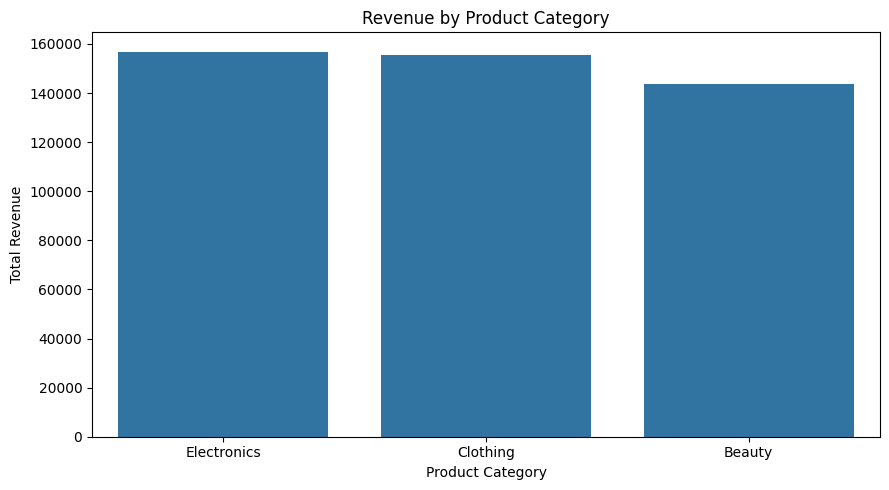

In [74]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_revenue,
    x="Product Category",
    y="Total Revenue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

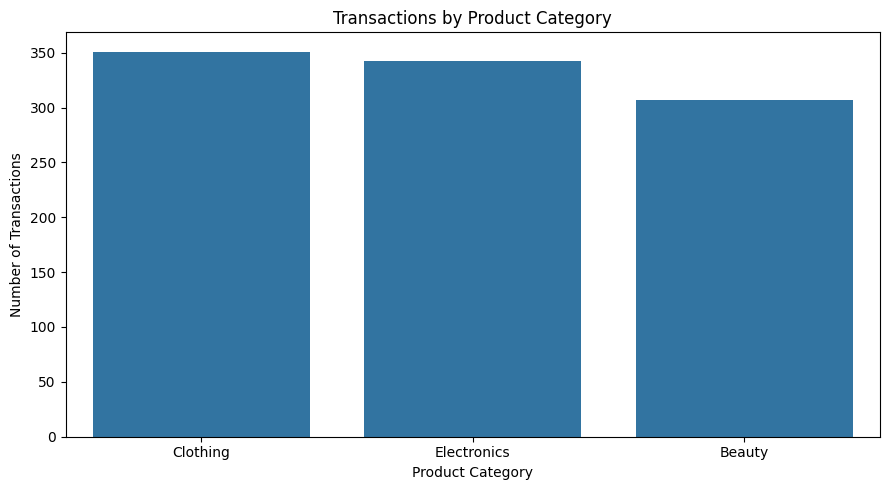

In [75]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_transactions,
    x="Product Category",
    y="Transaction Count"
)

plt.title("Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [76]:
top_category = category_revenue.iloc[0]

print("Top Revenue-Generating Category:")
print("Category:", top_category["Product Category"])
print("Revenue:", top_category["Total Revenue"])

Top Revenue-Generating Category:
Category: Electronics
Revenue: 156905


### Observation

The category-level analysis identifies which product categories generate the highest revenue and transaction volume. The highest-revenue category represents an important area for inventory planning, marketing investment, and promotional strategies.

## 6. Correlation Analysis

Correlation analysis is used to examine relationships between the numerical variables in the retail sales dataset.

The analysis focuses on Age, Quantity, Price per Unit, and Total Amount.

In [77]:
# Select numerical columns
numerical_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

correlation_matrix = df[numerical_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,Age,Quantity,Price per Unit,Total Amount
Age,1.00,-0.02,-0.04,-0.06
Quantity,-0.02,1.00,0.02,0.37
Price per Unit,-0.04,0.02,1.00,0.85
Total Amount,-0.06,0.37,0.85,1.00


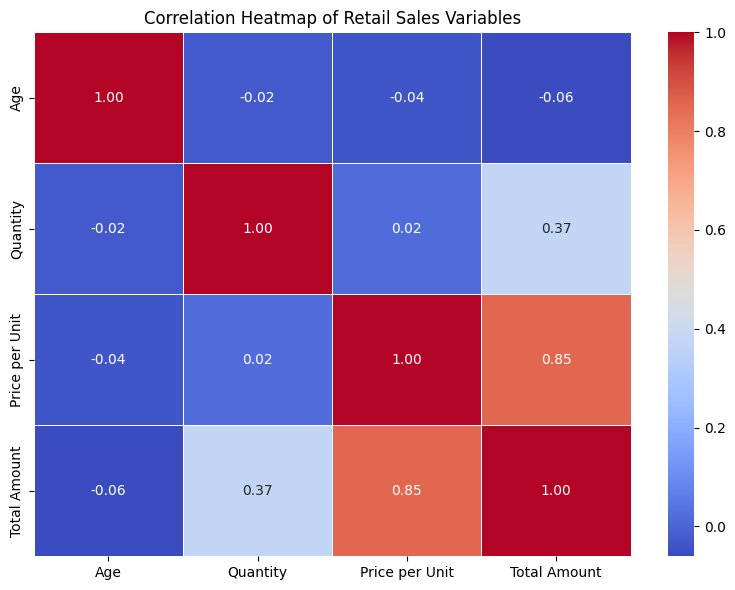

In [78]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Retail Sales Variables")

plt.tight_layout()
plt.show()

## 7. Additional Analysis: Quantity and Transaction Value

This analysis examines the relationship between quantity purchased and total transaction amount.

The objective is to determine whether larger quantities generally result in higher transaction values and to identify unusual purchasing patterns.

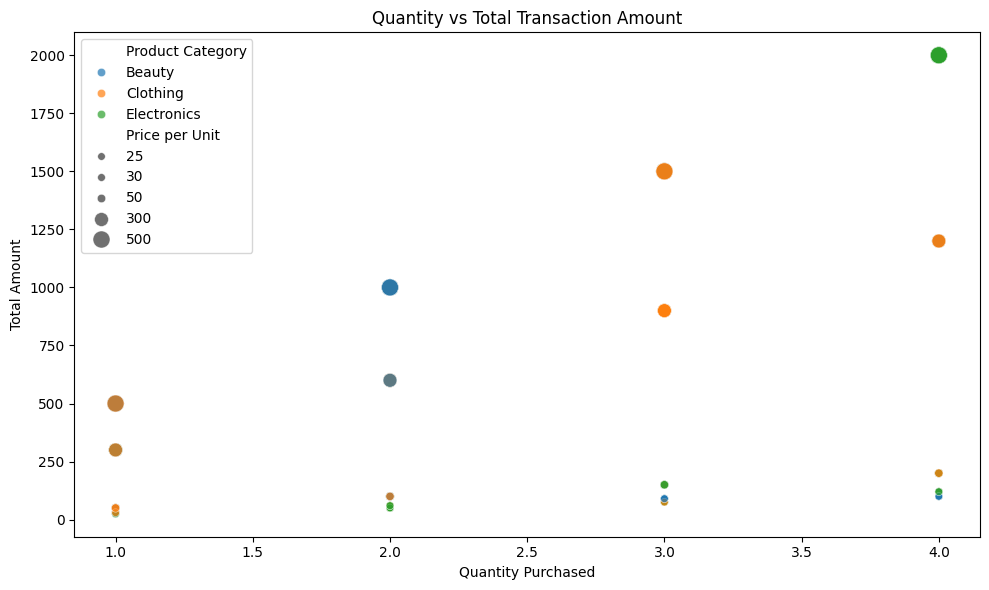

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total Amount",
    hue="Product Category",
    size="Price per Unit",
    sizes=(30, 150),
    alpha=0.7
)

plt.title("Quantity vs Total Transaction Amount")
plt.xlabel("Quantity Purchased")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows the relationship between quantity purchased and total transaction value. Transactions involving larger quantities generally have higher total amounts, although the price per unit also influences the final transaction value. Differences between product categories may indicate varying pricing and purchasing patterns.

## 8. Business Recommendations

Based on the exploratory data analysis, the following recommendations can be made:

### 1. Focus on High-Revenue Categories

The category generating the highest revenue should receive appropriate inventory levels and marketing attention. Promotions can be designed around products in high-performing categories to maximize revenue.

### 2. Target High-Value Customer Segments

Age-group and gender analysis can be used to identify customer segments contributing strongly to sales. Targeted promotions and personalized campaigns can be developed for these segments.

### 3. Optimize Pricing and Quantity-Based Promotions

The relationship between quantity, price per unit, and total transaction value can help identify opportunities for volume discounts and promotional bundles. Encouraging customers to purchase multiple units can increase transaction value while maintaining attractive pricing.

## 9. Conclusion

This project performed exploratory data analysis on a retail sales dataset containing 1,000 transactions.

The analysis examined sales trends, customer demographics, product categories, and relationships between numerical variables. Monthly and quarterly sales trends were analyzed to understand changes in revenue over time. Customer age-group and gender analysis provided insights into different customer segments.

Category-level analysis identified the revenue contribution and transaction volume of different product categories. Correlation analysis was used to examine relationships between age, quantity, price per unit, and total transaction amount. An additional scatter plot explored the relationship between quantity purchased and transaction value.

The analysis provides useful insights that can support inventory planning, customer targeting, pricing decisions, and promotional strategies.

One limitation of the dataset is that it does not contain individual product names, so a true Top 10 product-level analysis could not be performed. Instead, product categories were analyzed.

Overall, the project demonstrates how exploratory data analysis and visualization can be used to convert retail transaction data into actionable business insights.